# EDA — Predicción de precios de viviendas (Ames Iowa Housing)
### Parte 2: Análisis exploratorio de los datos (EDA)

## 0. Importación de librerías y carga de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv("../data/Ames_Iowa_Housing_Dataset.csv")
print("Dimensiones del dataset:", df.shape)
df.head()
print(df.info())

Dimensiones del dataset: (2930, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 no

## 1. Estadística descriptiva y distribución de `SalePrice`

`SalePrice` es la variable objetivo del proyecto. Analizamos sus estadísticos principales y su forma de distribución.

In [16]:
# Estadísticos descriptivos
desc = df['SalePrice'].describe()
print(desc)

print(f"\nAsimetría (skewness): {df['SalePrice'].skew():.2f}")
print(f"Curtosis: {df['SalePrice'].kurtosis():.2f}")

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

Asimetría (skewness): 1.74
Curtosis: 5.12


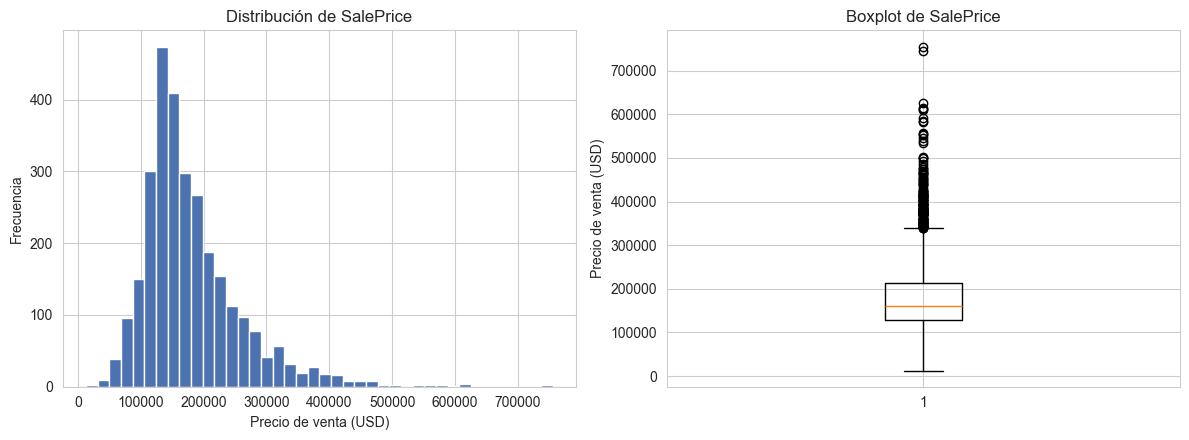

In [ ]:
# Visualización: histograma + boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df['SalePrice'], bins=40, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribución de SalePrice')
axes[0].set_xlabel('Precio de venta (USD)')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df['SalePrice'], vert=True)
axes[1].set_title('Boxplot de SalePrice')
axes[1].set_ylabel('Precio de venta (USD)')

plt.tight_layout()
plt.savefig('../images/saleprice_distribucion.png', dpi=130)
plt.show()

**Interpretación:**

La distribución de `SalePrice` presenta un **sesgo positivo marcado** (skewness ≈ 1.74). La mayoría de las viviendas
se concentra entre USD 100.000 y USD 220.000, mientras que una cola de propiedades de alto valor (hasta USD 755.000)
estira la distribución hacia la derecha. La media (≈ USD 180.796) es notablemente mayor que la mediana (USD 160.000),
lo que confirma la asimetría.

> Esto sugiere que, para el modelamiento posterior, podría convenir aplicar una **transformación logarítmica**
> sobre `SalePrice` para acercar su distribución a una normal.

## 2. Identificación de valores faltantes, outliers y anomalías

### 2.1 Valores faltantes

In [18]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0]
missing_df

,missing_count,missing_pct
Pool QC,2917,99.56
Misc Feature,2824,96.38
Alley,2732,93.24
Fence,2358,80.48
Mas Vnr Type,1775,60.58
Fireplace Qu,1422,48.53
Lot Frontage,490,16.72
Garage Qual,159,5.43
Garage Yr Blt,159,5.43
Garage Cond,159,5.43


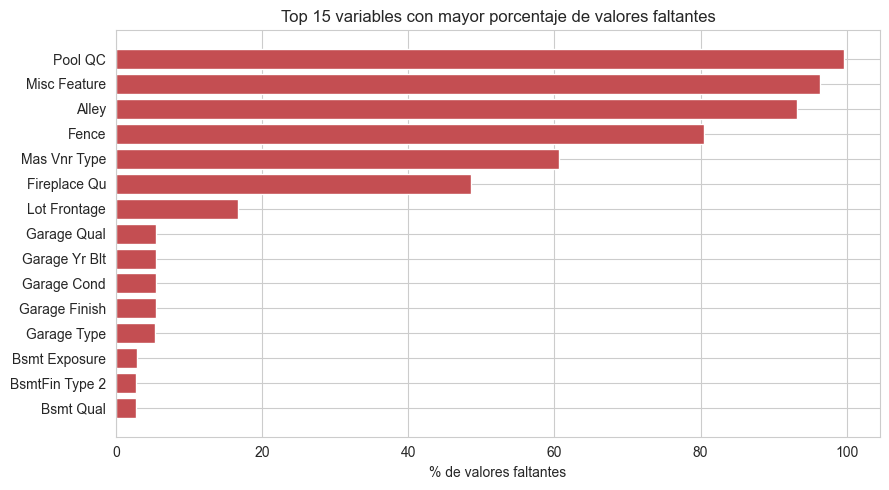

In [ ]:
# Visualización de las variables con más valores faltantes
top_missing = missing_df.head(15)

plt.figure(figsize=(9,5))
plt.barh(top_missing.index[::-1], top_missing['missing_pct'][::-1], color='#C44E52')
plt.xlabel('% de valores faltantes')
plt.title('Top 15 variables con mayor porcentaje de valores faltantes')
plt.tight_layout()
plt.savefig('../images/valores_faltantes.png', dpi=130)
plt.show()

In [20]:
# Detalle de las dos variables clave: Lot Frontage y Garage Yr Blt
for col in ['Lot Frontage', 'Garage Yr Blt']:
    nulos = df[col].isnull().sum()
    print(f"--- {col} ---")
    print(df[col].describe())
    print(f"Nulos: {nulos} ({nulos/len(df)*100:.2f}%)\n")

--- Lot Frontage ---
count    2440.000000
mean       69.224590
std        23.365335
min        21.000000
25%        58.000000
50%        68.000000
75%        80.000000
max       313.000000
Name: Lot Frontage, dtype: float64
Nulos: 490 (16.72%)

--- Garage Yr Blt ---
count    2771.000000
mean     1978.132443
std        25.528411
min      1895.000000
25%      1960.000000
50%      1979.000000
75%      2002.000000
max      2207.000000
Name: Garage Yr Blt, dtype: float64
Nulos: 159 (5.43%)



### 2.2 Outliers (método IQR)

In [21]:
def detectar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    outliers = serie[(serie < limite_inf) | (serie > limite_sup)]
    return outliers, limite_inf, limite_sup

for col in ['SalePrice', 'Lot Frontage']:
    outliers, low, high = detectar_outliers_iqr(df[col].dropna())
    print(f"--- {col} ---")
    print(f"Límites IQR: [{low:.1f}, {high:.1f}]")
    print(f"N° de outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)\n")

--- SalePrice ---
Límites IQR: [3500.0, 339500.0]
N° de outliers: 137 (4.68%)

--- Lot Frontage ---
Límites IQR: [25.0, 113.0]
N° de outliers: 187 (6.38%)



### 2.3 Anomalías detectadas

In [84]:
# Anomalía en Garage Yr Blt: años fuera de rango razonable
anomalia_garage = df[df['Garage Yr Blt'] > 2020][['PID', 'Year Built', 'Year Remod/Add', 'Garage Yr Blt', 'Garage Type']]
anomalia_garage

,PID,Year Built,Year Remod/Add,Garage Yr Blt,Garage Type
2260,916384070,2006,2007,2207.0,Attchd


In [23]:
# Outlier clásico del dataset Ames: viviendas muy grandes con precio inconsistente
df[df['Gr Liv Area'] > 4000][['PID', 'Gr Liv Area', 'SalePrice']]

,PID,Gr Liv Area,SalePrice
1498,908154235,5642,160000
1760,528320050,4476,745000
1767,528351010,4316,755000
2180,908154195,5095,183850
2181,908154205,4676,184750


### 3. Correlacion entre variables numericas y la variable objetivo

In [ ]:
#Aqui buscamos la cantidad de columnas numericas dentro del dataset
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Cantidad de variables numéricas: {len(num_cols)}")


Cantidad de variables numéricas: 39


In [66]:
# Correlación con SalePrice
corr = df[num_cols].corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

corr.head(16)


SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Lot Frontage      0.357318
Name: SalePrice, dtype: float64

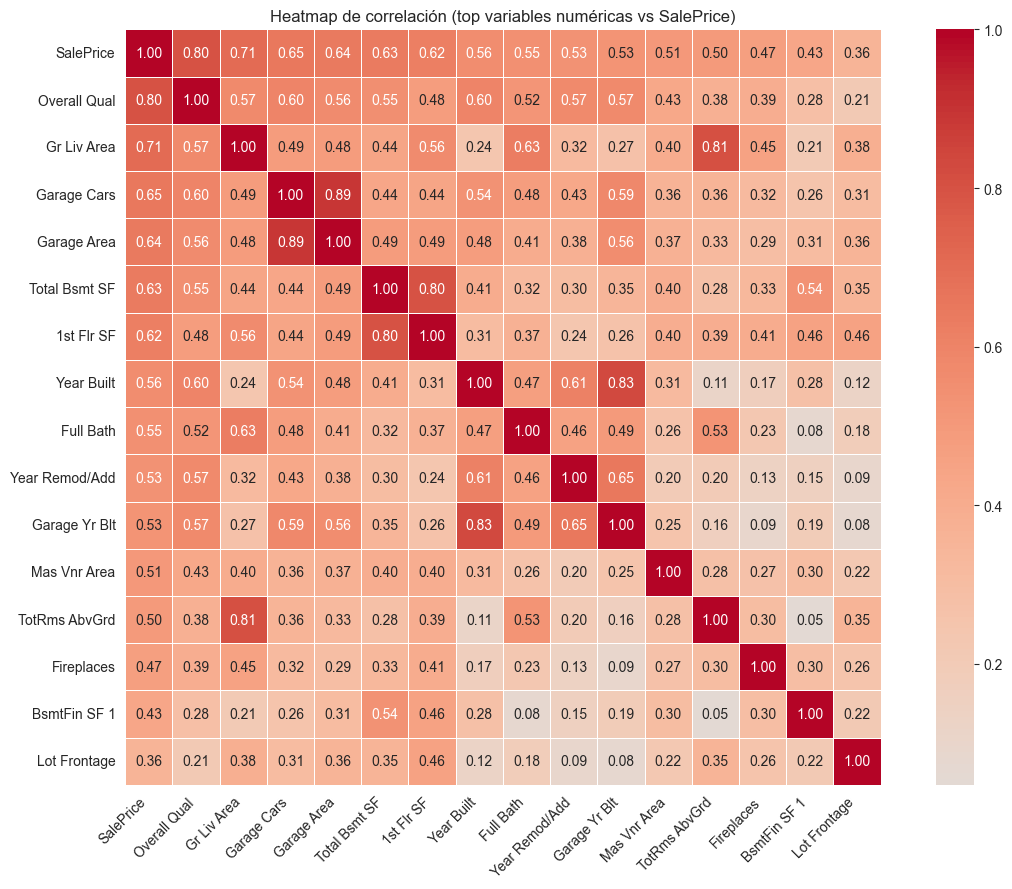

In [ ]:
#aqui tomamos las 15 variables con mayor correlacion con la variable saleprice
corr_target = df[num_cols].corr(numeric_only=True)['SalePrice'].drop('SalePrice')
top_vars = corr_target.abs().sort_values(ascending=False).head(15).index.tolist()

#incluimos salesprice como primera variable para el heatmap
vars_heatmap = ['SalePrice'] + top_vars
#se genera la matriz de correlacion 
matriz_corr = df[vars_heatmap].corr(numeric_only=True)

#generamos el grafico de calor o heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Heatmap de correlación (top variables numéricas vs SalePrice)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../images/matriz_correlacion.png', dpi=130)
plt.show()

## 4. Relacion del costo de una vivienda acorde al barrio en que se encuentra

4.1 Aqui buscamos el promedio del valor de una vivienda por barrio, la mediana del valor  y la cantidad de viviendas que hay en cada uno de los barrios

In [86]:
df.groupby('Neighborhood')['SalePrice'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)

,mean,median,count
Neighborhood,,,
NoRidge,330319.126761,302000.0,71
StoneBr,324229.196078,319000.0,51
NridgHt,322018.265060,317750.0,166
GrnHill,280000.000000,280000.0,2
Veenker,248314.583333,250250.0,24
Timber,246599.541667,232106.5,72
Somerst,229707.324176,225500.0,182
ClearCr,208662.090909,197500.0,44
Crawfor,207550.834951,200624.0,103


4.2 Generamos una visualizacion de la relacion que hay entre el costo de la vivienda y el barrio en que se ubica

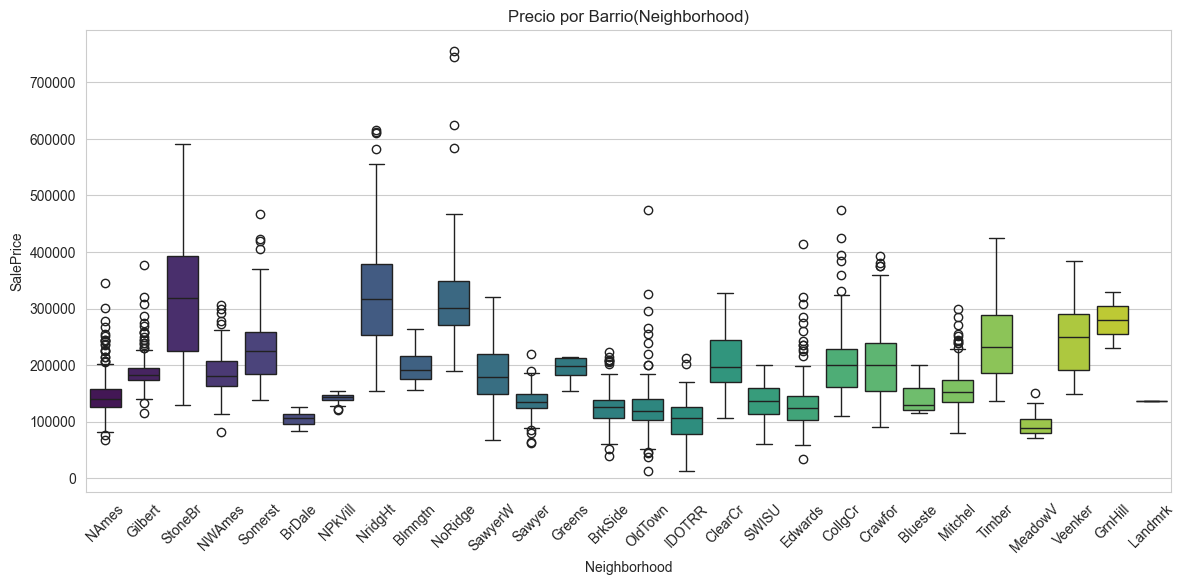

In [ ]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Neighborhood', y='SalePrice',hue='Neighborhood', palette='viridis')
plt.xticks(rotation=45)
plt.title('Precio por Barrio(Neighborhood)')
plt.savefig('../images/relacion_Barrio.png', dpi=130)
plt.show()

4.3 Generamos una visualizacion que muestra como se relaciona la variable terminanciones `Overall Qual` con la variable valor de la vivienda `SalePrice`

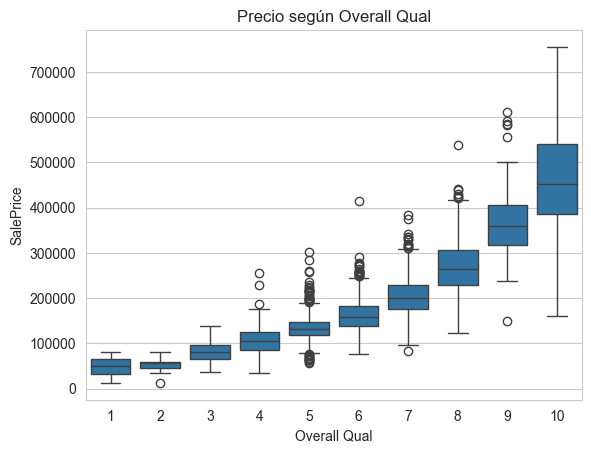

In [ ]:
sns.boxplot(data=df, x='Overall Qual', y='SalePrice')
plt.title('Precio según Overall Qual')
plt.savefig('../images/Relacion_Terminaciones.png', dpi=130)
plt.show()

## 5. Conclusiones de la parte 2

- En variables como `Pool QC`, `Alley`, `Fence`, `Garage*` y `Bsmt*`, el valor nulo **no representa un dato
perdido por error**, sino la **ausencia física del atributo** (ej. una casa sin piscina no tiene `Pool QC`,
una casa sin garaje no tiene `Garage Yr Blt`). Esto es clave para decidir la estrategia de imputación,
no corresponde imputar con media/moda, sino con una categoría explícita como `"None"` o `0`.

- `Lot Frontage` (16.72% de nulos) es distinto: parece ser información no registrada, por lo que requiere
una imputación más cuidadosa (ej. mediana agrupada por `Neighborhood`).

- `SalePrice`: **137 outliers (4.68%)** fuera del rango IQR [USD 3.500 – USD 339.500], concentrados en el
extremo superior (viviendas de alto valor).

- `Lot Frontage`: **187 outliers (6.38%)**, principalmente en el extremo superior (valores de hasta 313 pies,
  muy por encima del rango típico de 25–113 pies).

- **Anomalía detectada:** el registro `PID 916384070` tiene `Garage Yr Blt = 2207`, un año que no existe en
el contexto del dataset (la vivienda fue construida en 2006 y remodelada en 2007). Es prácticamente seguro
que se trata de un **error de tipeo** (2007 registrado como 2207), y deberá corregirse en la Parte 3.

- dos propiedades con `Gr Liv Area` superior a 4.000 pies² (4.316 y 4.476 pies²) se
vendieron en USD 745.000 y USD 755.000 — una combinación esperable de vivienda grande y precio alto.
Sin embargo, otra propiedad de **5.642 pies²** se vendió en solo **USD 160.000**, muy por debajo de lo
esperado para su tamaño. Este caso atípico ameritará revisión en la Parte 3 (podría tratarse de una venta
entre familiares o una condición particular de la propiedad no capturada por otras variables).

- El Vecindario(`Neighborhood`) y terminaciones (`Overall Qual`) muestran diferencias claras en los precios lo cual nos explica un poco el porque el valor de algunas viviendas pero la variable de `Neighborhood` podria generar un sesgo socioeconomico(Sesgo de muestreo) en cuanto a la prediccion de precios ya que hay un desbalance entre la cantidad de propiedades que hay por vecindarios 